### Question 1 a


In [7]:
import os
import warnings
warnings.filterwarnings("ignore")



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)


# ============================================================
# 0. Basic configuration
# ============================================================

PATH_X_TR = "./DD/X_TR.csv"
PATH_y_TR = "./DD/Y_TR.csv"



OUTPUT_DIR = "q1a_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42




#SAMPLE_SIZES = [140, 350, 700, 1400, 2800, 5600]

SAMPLE_SIZES = [140, 350, 700, 1400, 2800, 5600]
SAMPLE_SIZES = [5600,2800,1400,700,350,140]
print("SAMPLE SIZES ", SAMPLE_SIZES)

# 太慢了 调整为3
REPEATS = 3

TEST_SIZE = 0.30

# Cross-validation folds inside training set
CV_FOLDS = 4

# Feature selection 数量
# 保留特征数量的设置
FEATURE_K_OPTIONS = [50, 100, 200, 400]

# PCA 保留方差比例
PCA_OPTIONS = [0.80, 0.90, 0.95]


SAMPLE SIZES  [5600, 2800, 1400, 700, 350, 140]


In [8]:

# ============================================================
# 1. Load data
# ============================================================

def load_data(path_x, path_y):
    """
    Read X and y from csv files.
    This function is written to handle common label-file problems.
    """

    X = pd.read_csv(path_x, index_col=0)

    y_df = pd.read_csv(path_y)

    print("Raw X shape:", X.shape)
    print("Raw y shape:", y_df.shape)
    print("Raw y columns:", y_df.columns.tolist())

    # Case 1: y file has only one column
    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]

    # Case 2: y file has two columns, first column is probably index
    elif y_df.shape[1] == 2:
        y = y_df.iloc[:, 1]

    else:
        raise ValueError(
            "y file has more than 2 columns. Please inspect y_TR.csv manually."
        )

    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)

    print("\nAfter processing:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Number of classes:", y.nunique())
    print("\nClass distribution:")
    print(y.value_counts().sort_index())

    return X, y


X_TR, y_TR = load_data(PATH_X_TR, PATH_y_TR)

N_FEATURES = X_TR.shape[1]
N_CLASSES = y_TR.nunique()

print("\nNumber of features:", N_FEATURES)
print("Number of classes:", N_CLASSES)


Raw X shape: (8080, 819)
Raw y shape: (8080, 1)
Raw y columns: ['class']

After processing:
X shape: (8080, 819)
y shape: (8080,)
Number of classes: 7

Class distribution:
class
1    1071
2    1308
3    1214
4     489
5    1164
6    1204
7    1630
Name: count, dtype: int64

Number of features: 819
Number of classes: 7


In [9]:

# ============================================================
# 2. Balanced sampling
# ============================================================

def balanced_sample(X, y, n_total, random_state=0):
    """
    Draw approximately balanced sample from all classes.
    If n_total is larger than available data, use all data.
    """

    rng = np.random.default_rng(random_state)

    X = pd.DataFrame(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    classes = np.sort(y.unique())
    n_classes = len(classes)

    n_per_class = n_total // n_classes

    selected_indices = []

    for c in classes:
        idx_c = np.where(y == c)[0]
        n_c = min(n_per_class, len(idx_c))

        chosen = rng.choice(idx_c, size=n_c, replace=False)
        selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    X_sub = X.iloc[selected_indices].reset_index(drop=True)
    y_sub = y.iloc[selected_indices].reset_index(drop=True)

    return X_sub, y_sub


In [66]:

# ============================================================
# 3. Define pipelines
# ============================================================

def make_pipelines():
    """
    All models use:
    StandardScaler -> SelectKBest -> PCA -> Classifier

    This ensures:
    1. feature selection happens only inside training data
    2. PCA happens only inside training data
    3. no data leakage occurs
    """

    pipelines = {}



    # --------------------------------------------------------
    # L1 sparse logistic regression
    # --------------------------------------------------------
    pipelines["L1_Logistic"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced"
        ))
    ])

    # --------------------------------------------------------
    # Shrinkage LDA
    # --------------------------------------------------------
    pipelines["Shrinkage_LDA"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        ))
    ])




    # --------------------------------------------------------
    # RBF SVM
    # --------------------------------------------------------
    pipelines["RBF_SVM"] = Pipeline([
        ("scaler", RBF_SVMStandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"
        ))
    ])

    # --------------------------------------------------------
    # Random Forest
    # Random Forest normally does not need scaling or PCA,
    # but here we still include feature selection + PCA
    # to keep the pipeline comparable.
    # --------------------------------------------------------
    pipelines["RandomForest"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    return pipelines


pipelines = make_pipelines()


In [67]:

# ============================================================
# 4. Define parameter grids for inner cross-validation
# ============================================================

def make_param_grids():
    """
    Parameter grids are deliberately not too large,
    otherwise the experiment can become very slow.
    """

    common_fs_pca = {
        "select__k": FEATURE_K_OPTIONS,
        "pca__n_components": PCA_OPTIONS
    }

    param_grids = {}


    param_grids["L1_Logistic"] = {
        **common_fs_pca,
        "clf__C": [0.05, 0.1, 0.5, 1]
    }

    param_grids["Shrinkage_LDA"] = {
        **common_fs_pca
    }





    param_grids["RBF_SVM"] = {
        **common_fs_pca,
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.01, 0.001]
    }

    param_grids["RandomForest"] = {
        **common_fs_pca,
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5]
    }

    return param_grids


param_grids = make_param_grids()


In [12]:

# ============================================================
# 5. Helper functions
# ============================================================

def adjust_param_grid_for_sample_size(param_grid, X_train):
    """
    SelectKBest k cannot be larger than number of features.
    Also, PCA n_components as float is okay.
    """

    adjusted_grid = param_grid.copy()

    if "select__k" in adjusted_grid:
        valid_k = [k for k in adjusted_grid["select__k"] if k <= X_train.shape[1]]

        if len(valid_k) == 0:
            valid_k = [min(50, X_train.shape[1])]

        adjusted_grid["select__k"] = valid_k

    return adjusted_grid


def fit_with_inner_cv(model, param_grid, X_train, y_train):
    """
    Fit model using inner cross-validation.
    """

    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        error_score=np.nan
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_, grid.best_score_


def extract_selected_feature_count(fitted_pipeline):
    """
    Count how many original features were kept by SelectKBest.
    """

    if "select" not in fitted_pipeline.named_steps:
        return np.nan

    selector = fitted_pipeline.named_steps["select"]
    selected_mask = selector.get_support()

    return int(np.sum(selected_mask))


def extract_selected_feature_indices(fitted_pipeline):
    """
    Return selected original feature indices.
    """

    if "select" not in fitted_pipeline.named_steps:
        return []

    selector = fitted_pipeline.named_steps["select"]
    selected_idx = np.where(selector.get_support())[0]

    return selected_idx.tolist()


def extract_pca_components_count(fitted_pipeline):
    """
    Count number of PCA components used after fitting.
    """

    if "pca" not in fitted_pipeline.named_steps:
        return np.nan

    pca = fitted_pipeline.named_steps["pca"]

    if hasattr(pca, "n_components_"):
        return int(pca.n_components_)

    return np.nan


def evaluate_model(model, X_test, y_test):
    """
    Compute overall and class-specific metrics.
    """

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_test, y_pred)

    return acc, macro_f1, report, cm, y_pred


In [26]:

# ============================================================
# 6. Main experiment: sample size effect
# ============================================================


## 这是模型训练的主要流程

all_results = []
all_class_reports = []
all_confusion_matrices = {}
all_best_params = []
all_selected_features = {}

for sample_size in SAMPLE_SIZES:

    print("\n" + "=" * 70)
    print(f"Sample size: {sample_size}")
    print("=" * 70)

    for repeat in range(REPEATS):

        print(f"\nRepeat {repeat + 1}/{REPEATS}")

        # ----------------------------------------------------
        # Balanced subsampling
        # ----------------------------------------------------
        X_sub, y_sub = balanced_sample(
            X_TR,
            y_TR,
            n_total=sample_size,
            random_state=1000 * sample_size + repeat
        )

        # ----------------------------------------------------
        # Train/test split
        # ----------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub,
            y_sub,
            test_size=TEST_SIZE,
            stratify=y_sub,
            random_state=repeat
        )

        for model_name, pipeline in pipelines.items():

            print(f"  Fitting {model_name}...")

            model = clone(pipeline)

            param_grid = adjust_param_grid_for_sample_size(
                param_grids[model_name],
                X_train
            )

            try:
                best_model, best_params, cv_score = fit_with_inner_cv(
                    model,
                    param_grid,
                    X_train,
                    y_train
                )

                acc, macro_f1, report, cm, y_pred = evaluate_model(
                    best_model,
                    X_test,
                    y_test
                )

                selected_count = extract_selected_feature_count(best_model)
                selected_idx = extract_selected_feature_indices(best_model)
                pca_count = extract_pca_components_count(best_model)

                all_results.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "accuracy": acc,
                    "macro_f1": macro_f1,
                    "inner_cv_macro_f1": cv_score,
                    "selected_feature_count": selected_count,
                    "pca_component_count": pca_count
                })

                all_best_params.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "best_params": best_params
                })

                all_confusion_matrices[(sample_size, repeat, model_name)] = cm
                all_selected_features[(sample_size, repeat, model_name)] = selected_idx

                # class-specific report
                for cls in sorted(y_TR.unique()):
                    cls_str = str(cls)

                    if cls_str in report:
                        all_class_reports.append({
                            "sample_size": sample_size,
                            "repeat": repeat,
                            "model": model_name,
                            "class": cls,
                            "precision": report[cls_str]["precision"],
                            "recall": report[cls_str]["recall"],
                            "f1_score": report[cls_str]["f1-score"],
                            "support": report[cls_str]["support"]
                        })

                print(
                    f"    acc={acc:.4f}, macro_f1={macro_f1:.4f}, "
                    f"selected={selected_count}, pca={pca_count}"
                )

            except Exception as e:
                print(f"    Failed: {model_name}, error: {e}")

                all_results.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "accuracy": np.nan,
                    "macro_f1": np.nan,
                    "inner_cv_macro_f1": np.nan,
                    "selected_feature_count": np.nan,
                    "pca_component_count": np.nan
                })



Sample size: 5600

Repeat 1/3
  Fitting FS_PCA_L1_Logistic...


KeyboardInterrupt: 

In [8]:

# ============================================================
# 7. Save raw results
# ============================================================

results_df = pd.DataFrame(all_results)
class_reports_df = pd.DataFrame(all_class_reports)
best_params_df = pd.DataFrame(all_best_params)

results_path = os.path.join(OUTPUT_DIR, "q1a_results_all.csv")
class_reports_path = os.path.join(OUTPUT_DIR, "q1a_class_reports_all.csv")
best_params_path = os.path.join(OUTPUT_DIR, "q1a_best_params.csv")

results_df.to_csv(results_path, index=False)
class_reports_df.to_csv(class_reports_path, index=False)
best_params_df.to_csv(best_params_path, index=False)

print("\nSaved:")
print(results_path)
print(class_reports_path)
print(best_params_path)



Saved:
q1a_results\q1a_results_all.csv
q1a_results\q1a_class_reports_all.csv
q1a_results\q1a_best_params.csv


In [9]:

# ============================================================
# 8. Summarize overall performance
# ============================================================

summary = results_df.groupby(["sample_size", "model"]).agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    inner_cv_macro_f1_mean=("inner_cv_macro_f1", "mean"),
    selected_feature_count_mean=("selected_feature_count", "mean"),
    pca_component_count_mean=("pca_component_count", "mean")
).reset_index()

summary_path = os.path.join(OUTPUT_DIR, "q1a_summary.csv")
summary.to_csv(summary_path, index=False)

print("\nOverall summary:")
print(summary)

print("\nSaved:")
print(summary_path)



Overall summary:
    sample_size                 model  accuracy_mean  accuracy_std  \
0           140    FS_PCA_L1_Logistic       0.642857      0.047619   
1           140        FS_PCA_RBF_SVM       0.722222      0.036370   
2           140   FS_PCA_RandomForest       0.730159      0.036370   
3           140  FS_PCA_Shrinkage_LDA       0.753968      0.036370   
4           350    FS_PCA_L1_Logistic       0.771429      0.043644   
5           350        FS_PCA_RBF_SVM       0.838095      0.009524   
6           350   FS_PCA_RandomForest       0.803175      0.029096   
7           350  FS_PCA_Shrinkage_LDA       0.815873      0.010997   
8           700    FS_PCA_L1_Logistic       0.849206      0.035741   
9           700        FS_PCA_RBF_SVM       0.900000      0.028966   
10          700   FS_PCA_RandomForest       0.865079      0.005499   
11          700  FS_PCA_Shrinkage_LDA       0.874603      0.055601   
12         1400    FS_PCA_L1_Logistic       0.903968      0.007274   
13

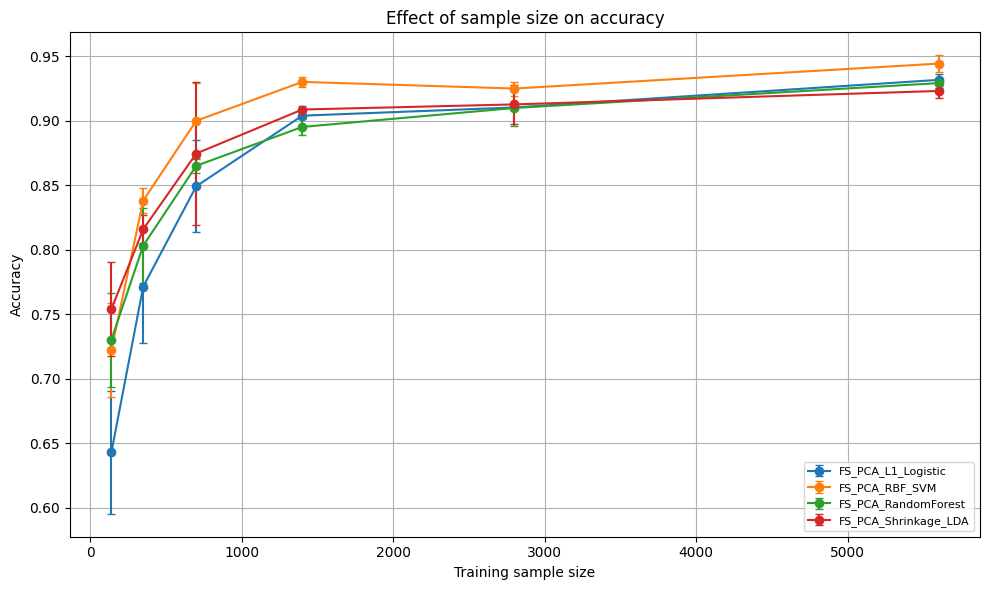

Saved: q1a_results\plot_sample_size_accuracy.png


In [10]:

# ============================================================
# 9. Plot: sample size vs accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.errorbar(
        tmp["sample_size"],
        tmp["accuracy_mean"],
        yerr=tmp["accuracy_std"],
        marker="o",
        capsize=3,
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Accuracy")
plt.title("Effect of sample size on accuracy")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_sample_size_accuracy.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


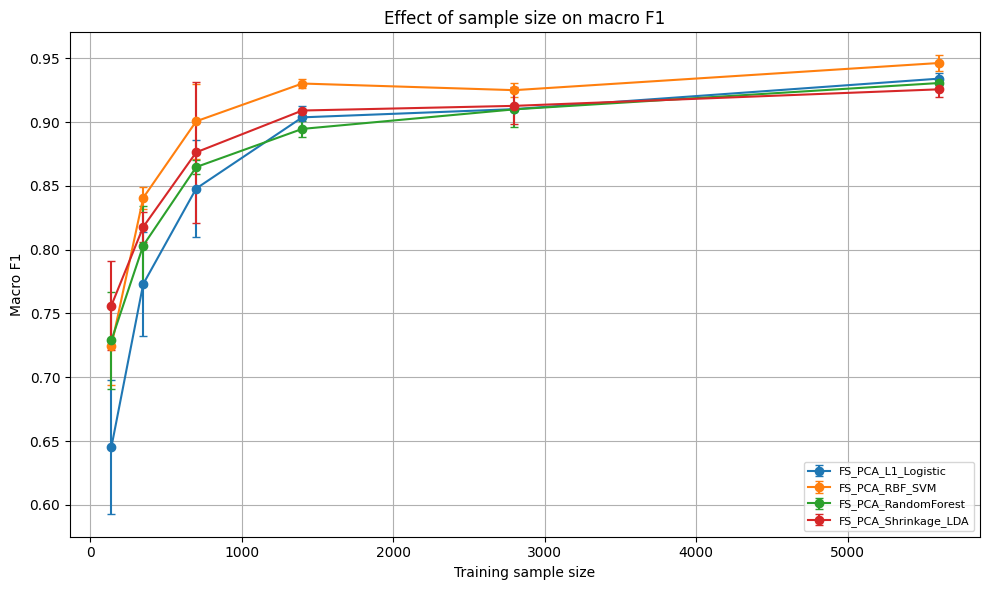

Saved: q1a_results\plot_sample_size_macro_f1.png


In [11]:

# ============================================================
# 10. Plot: sample size vs macro F1
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.errorbar(
        tmp["sample_size"],
        tmp["macro_f1_mean"],
        yerr=tmp["macro_f1_std"],
        marker="o",
        capsize=3,
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Macro F1")
plt.title("Effect of sample size on macro F1")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_sample_size_macro_f1.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


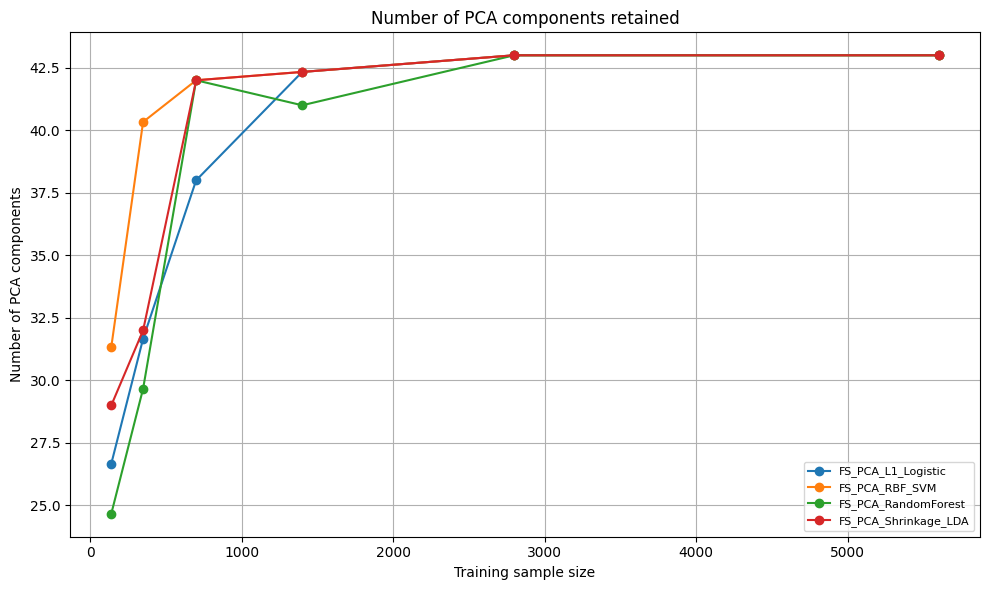

Saved: q1a_results\plot_pca_component_count.png


In [13]:

# ============================================================
# 12. Plot: PCA component count
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.plot(
        tmp["sample_size"],
        tmp["pca_component_count_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Number of PCA components")
plt.title("Number of PCA components retained")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_pca_component_count.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [14]:

# ============================================================
# 13. Class-specific performance summary
# ============================================================

class_summary = class_reports_df.groupby(
    ["sample_size", "model", "class"]
).agg(
    precision_mean=("precision", "mean"),
    recall_mean=("recall", "mean"),
    f1_mean=("f1_score", "mean"),
    f1_std=("f1_score", "std"),
    support_mean=("support", "mean")
).reset_index()

class_summary_path = os.path.join(OUTPUT_DIR, "q1a_class_summary.csv")
class_summary.to_csv(class_summary_path, index=False)

print("\nClass-specific summary:")
print(class_summary.head())

print("\nSaved:")
print(class_summary_path)



Class-specific summary:
   sample_size               model  class  precision_mean  recall_mean  \
0          140  FS_PCA_L1_Logistic      1        0.790476     0.555556   
1          140  FS_PCA_L1_Logistic      2        0.666667     0.444444   
2          140  FS_PCA_L1_Logistic      3        0.452381     0.444444   
3          140  FS_PCA_L1_Logistic      4        0.849206     0.833333   
4          140  FS_PCA_L1_Logistic      5        0.888889     0.888889   

    f1_mean    f1_std  support_mean  
0  0.614219  0.113641           6.0  
1  0.525926  0.243770           6.0  
2  0.441026  0.035529           6.0  
3  0.837218  0.070011           6.0  
4  0.888889  0.096225           6.0  

Saved:
q1a_results\q1a_class_summary.csv


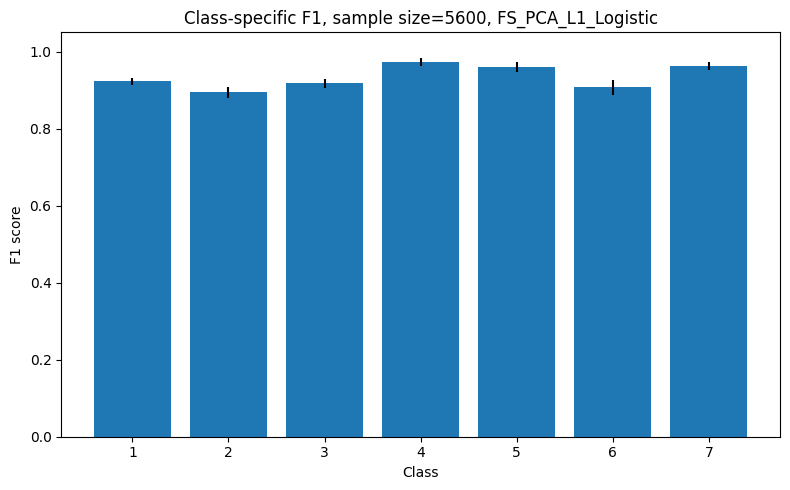

Saved: q1a_results\plot_class_f1_FS_PCA_L1_Logistic_n5600.png


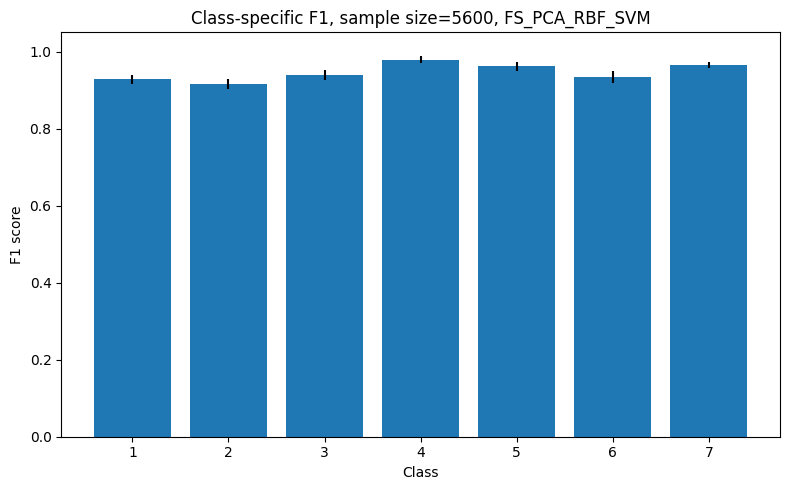

Saved: q1a_results\plot_class_f1_FS_PCA_RBF_SVM_n5600.png


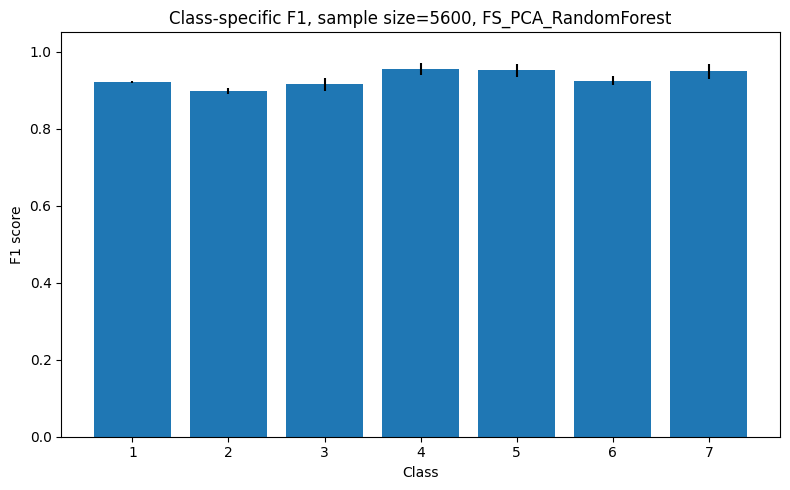

Saved: q1a_results\plot_class_f1_FS_PCA_RandomForest_n5600.png


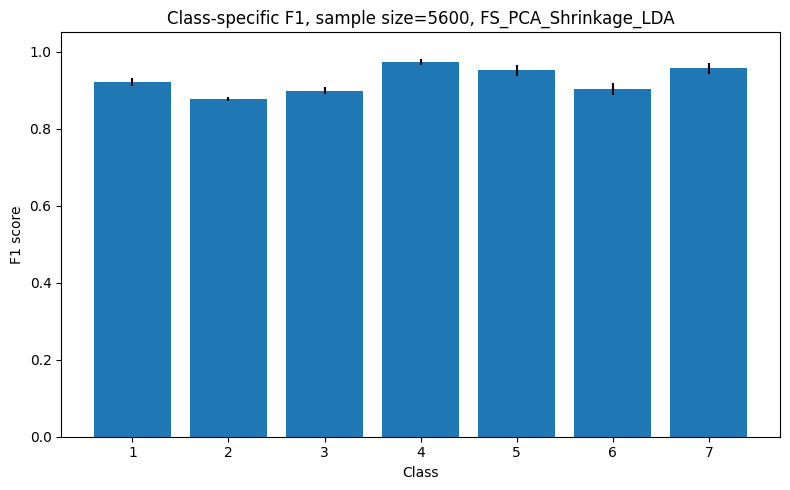

Saved: q1a_results\plot_class_f1_FS_PCA_Shrinkage_LDA_n5600.png


In [15]:

# ============================================================
# 14. Plot: class-specific F1 for largest sample size
# ============================================================

largest_sample_size = max(SAMPLE_SIZES)

class_largest = class_summary[
    class_summary["sample_size"] == largest_sample_size
]

for model_name in class_largest["model"].unique():

    tmp = class_largest[class_largest["model"] == model_name]

    plt.figure(figsize=(8, 5))
    plt.bar(tmp["class"].astype(str), tmp["f1_mean"], yerr=tmp["f1_std"])

    plt.xlabel("Class")
    plt.ylabel("F1 score")
    plt.title(f"Class-specific F1, sample size={largest_sample_size}, {model_name}")
    plt.ylim(0, 1.05)
    plt.tight_layout()

    fig_path = os.path.join(
        OUTPUT_DIR,
        f"plot_class_f1_{model_name}_n{largest_sample_size}.png"
    )

    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)


In [16]:

# ============================================================
# 15. Find best model
# ============================================================

model_ranking = results_df.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    macro_f1_mean=("macro_f1", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_std=("macro_f1", "std")
).reset_index()

model_ranking = model_ranking.sort_values(
    by="macro_f1_mean",
    ascending=False
)

model_ranking_path = os.path.join(OUTPUT_DIR, "q1a_model_ranking.csv")
model_ranking.to_csv(model_ranking_path, index=False)

print("\nModel ranking:")
print(model_ranking)

print("\nSaved:")
print(model_ranking_path)

best_model_name = model_ranking.iloc[0]["model"]
print("\nBest model based on average macro F1:", best_model_name)



Model ranking:
                  model  accuracy_mean  macro_f1_mean  accuracy_std  \
1        FS_PCA_RBF_SVM       0.876636       0.877858      0.081045   
3  FS_PCA_Shrinkage_LDA       0.864833       0.866262      0.067205   
2   FS_PCA_RandomForest       0.855465       0.855308      0.072938   
0    FS_PCA_L1_Logistic       0.834919       0.835664      0.106797   

   macro_f1_std  
1      0.080087  
3      0.066657  
2      0.073701  
0      0.106369  

Saved:
q1a_results\q1a_model_ranking.csv

Best model based on average macro F1: FS_PCA_RBF_SVM


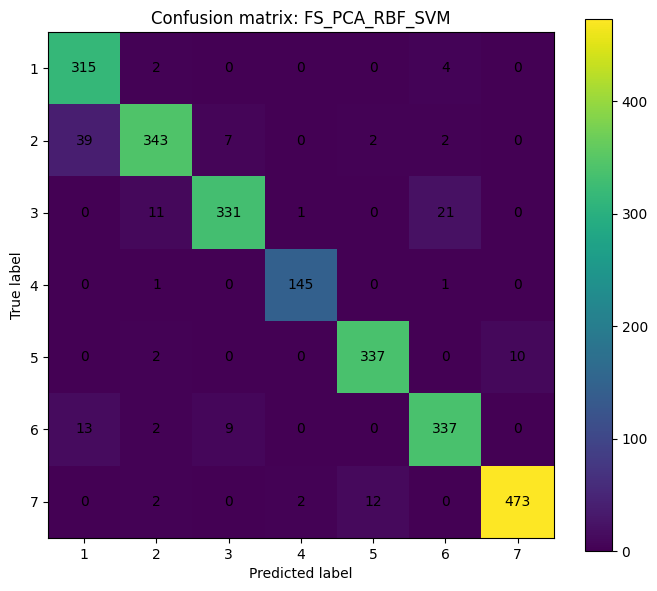

Saved: q1a_results\confusion_matrix_best_model_FS_PCA_RBF_SVM.png


In [17]:

# ============================================================
# 16. Refit best model on a large train/test split and plot confusion matrix
# ============================================================

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_TR,
    y_TR,
    test_size=TEST_SIZE,
    stratify=y_TR,
    random_state=RANDOM_STATE
)

best_pipeline = clone(pipelines[best_model_name])
best_param_grid = adjust_param_grid_for_sample_size(
    param_grids[best_model_name],
    X_train_full
)

best_model, best_params, best_cv_score = fit_with_inner_cv(
    best_pipeline,
    best_param_grid,
    X_train_full,
    y_train_full
)

y_pred_full = best_model.predict(X_test_full)

cm = confusion_matrix(y_test_full, y_pred_full)
classes = sorted(y_TR.unique())

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion matrix: {best_model_name}")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_best_model_{best_model_name}.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [18]:

# ============================================================
# 17. Inspect selected features in best model
# ============================================================

selected_features = extract_selected_feature_indices(best_model)
n_selected = len(selected_features)

print("\nBest model selected feature count:", n_selected)
print("First 30 selected feature indices:")
print(selected_features[:30])

selected_feature_path = os.path.join(
    OUTPUT_DIR,
    f"selected_features_best_model_{best_model_name}.csv"
)

pd.DataFrame({
    "selected_feature_index": selected_features
}).to_csv(selected_feature_path, index=False)

print("Saved:", selected_feature_path)



Best model selected feature count: 50
First 30 selected feature indices:
[6, 9, 18, 31, 53, 86, 88, 112, 129, 132, 135, 145, 152, 210, 241, 244, 250, 269, 271, 277, 297, 318, 355, 424, 432, 456, 459, 478, 502, 505]
Saved: q1a_results\selected_features_best_model_FS_PCA_RBF_SVM.csv


# Question 1 b


In [37]:
import numpy as np
import pandas as pd

def disrupt_features(X, mode="random_mask", fraction=0.2, seed=0, feature_indices=None):
    """
    Apply feature-level disruption.

    X can be pandas DataFrame or numpy array.

    Modes:
    - random_mask: randomly select a fraction of features and set them to 0 for all samples
    - sample_dropout: randomly set individual feature values to 0
    - gaussian_noise: add random Gaussian noise
    - important_mask: mask selected important features
    """

    rng = np.random.default_rng(seed)

    # Keep column names if X is DataFrame
    is_dataframe = isinstance(X, pd.DataFrame)

    if is_dataframe:
        X_array = X.to_numpy().copy()
        columns = X.columns
        index = X.index
    else:
        X_array = np.array(X).copy()
        columns = None
        index = None

    n_samples, n_features = X_array.shape

    if mode == "random_mask":
        n_mask = max(1, int(fraction * n_features))
        mask_features = rng.choice(n_features, size=n_mask, replace=False)
        X_array[:, mask_features] = 0

    elif mode == "sample_dropout":
        mask = rng.random(X_array.shape) < fraction
        X_array[mask] = 0

    elif mode == "gaussian_noise":
        feature_std = np.std(X_array, axis=0, keepdims=True)
        noise = rng.normal(
            loc=0,
            scale=fraction * feature_std,
            size=X_array.shape
        )
        X_array = X_array + noise

    elif mode == "important_mask":
        if feature_indices is None:
            raise ValueError("feature_indices must be provided for important_mask.")

        n_mask = max(1, int(fraction * len(feature_indices)))
        selected_features = feature_indices[:n_mask]
        X_array[:, selected_features] = 0

    else:
        raise ValueError(f"Unknown disruption mode: {mode}")

    if is_dataframe:
        return pd.DataFrame(X_array, columns=columns, index=index)
    else:
        return X_array

In [38]:
def multiclass_brier_score(y_true, y_prob, labels=np.arange(7)):
    """
    Multiclass Brier score.
    """

    labels = np.array(labels)
    n_classes = len(labels)

    y_true_onehot = np.zeros((len(y_true), n_classes))

    for i, label in enumerate(labels):
        y_true_onehot[:, i] = (y_true == label).astype(int)

    return np.mean(np.sum((y_prob - y_true_onehot) ** 2, axis=1))

In [39]:
import numpy as np
from sklearn.metrics import recall_score

def my_balanced_accuracy_score(y_true, y_pred, labels=None):
    """
    Compute balanced accuracy manually.

    Balanced accuracy = mean recall over all classes.
    """

    if labels is None:
        labels = np.unique(y_true)

    recalls = recall_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    return np.mean(recalls)

In [54]:


sample_sizes = [3500]

n_repeats = 3
test_size = 1000


disruption_modes = [
    "none","random_mask","sample_dropout","gaussian_noise"
]


CV_FOLDS= 4


unique_labels, class_counts = np.unique(y_TR, return_counts=True)


severity = 0.3
labels = np.arange(7)

In [55]:
from sklearn.metrics import log_loss

disruption_results = []
best_params_disruption = []

for n in sample_sizes:
    print("\n==============================")
    print(f"Sample size n = {n}")
    print("==============================")

    for repeat in range(n_repeats):
        print(f"\nRepeat {repeat + 1}/{n_repeats}")

        seed = 1000 + n + repeat

        X_sub, y_sub = balanced_sample(
            X_TR,
            y_TR,
            n_total=n,
            random_state=1000 * n + repeat
        )

        # ----------------------------------------------------
        # Train/test split
        # ----------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub,
            y_sub,
            test_size=TEST_SIZE,
            stratify=y_sub,
            random_state=repeat
        )

        print("train image size")
        print(X_train.shape)

        min_class_count = np.min(np.bincount(y_train))
        print("min_class_count", min_class_count)


        inner_cv = StratifiedKFold(
            n_splits=CV_FOLDS,
            shuffle=True,
            random_state=seed
        )

        for model_name, pipeline in pipelines.items():
            print(f"Training {model_name}...")

            param_grid = param_grids[model_name]
            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                cv=inner_cv,
                scoring="neg_log_loss",
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_

            best_params_disruption.append({
                "n": n,
                "repeat": repeat,
                "model": model_name,
                "best_params": grid.best_params_
            })

            # Evaluate on clean and disrupted test sets
            clean_metrics = None

            for mode in disruption_modes:
                if mode == "none":
                    X_eval = X_test.copy()
                else:
                    X_eval = disrupt_features(
                        X_test,
                        mode=mode,
                        seed=seed + 123
                    )

                y_pred = best_model.predict(X_eval)
                y_prob = best_model.predict_proba(X_eval)

                acc = accuracy_score(y_test, y_pred)
                bal_acc = my_balanced_accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="macro")

                ll = log_loss(
                    y_test,
                    y_prob,
                    labels=labels
                )

                brier = multiclass_brier_score(
                    y_test,
                    y_prob,
                    labels=labels
                )

                if mode == "none":
                    clean_metrics = {
                        "accuracy": acc,
                        "balanced_accuracy": bal_acc,
                        "f1_macro": f1,
                        "log_loss": ll,
                        "brier_score": brier
                    }

                disruption_results.append({
                    "n": n,
                    "repeat": repeat,
                    "model": model_name,
                    "disruption": mode,
                    "severity": severity,
                    "accuracy": acc,
                    "balanced_accuracy": bal_acc,
                    "f1_macro": f1,
                    "log_loss": ll,
                    "brier_score": brier,
                    "accuracy_drop": clean_metrics["accuracy"] - acc if clean_metrics is not None else 0,
                    "log_loss_increase": ll - clean_metrics["log_loss"] if clean_metrics is not None else 0,
                    "brier_increase": brier - clean_metrics["brier_score"] if clean_metrics is not None else 0
                })

disruption_df = pd.DataFrame(disruption_results)
best_params_disruption_df = pd.DataFrame(best_params_disruption)

disruption_df.head()


Sample size n = 3500

Repeat 1/3
train image size
(2442, 819)
min_class_count 0
Training FS_PCA_L1_Logistic...
Training FS_PCA_Shrinkage_LDA...
Training FS_PCA_RBF_SVM...
Training FS_PCA_RandomForest...

Repeat 2/3
train image size
(2442, 819)
min_class_count 0
Training FS_PCA_L1_Logistic...
Training FS_PCA_Shrinkage_LDA...
Training FS_PCA_RBF_SVM...
Training FS_PCA_RandomForest...

Repeat 3/3
train image size
(2442, 819)
min_class_count 0
Training FS_PCA_L1_Logistic...
Training FS_PCA_Shrinkage_LDA...
Training FS_PCA_RBF_SVM...
Training FS_PCA_RandomForest...


,n,repeat,model,disruption,severity,accuracy,balanced_accuracy,f1_macro,log_loss,brier_score,accuracy_drop,log_loss_increase,brier_increase
0,3500,0,FS_PCA_L1_Logistic,none,0.3,0.933142,0.933275,0.933256,9.509378,1.700901,0.000000,0.000000,0.000000
1,3500,0,FS_PCA_L1_Logistic,random_mask,0.3,0.845272,0.845637,0.839932,9.029466,1.629206,0.087870,-0.479912,-0.071694
2,3500,0,FS_PCA_L1_Logistic,sample_dropout,0.3,0.821394,0.821652,0.821076,7.596297,1.557384,0.111748,-1.913081,-0.143517
3,3500,0,FS_PCA_L1_Logistic,gaussian_noise,0.3,0.919771,0.919922,0.919977,9.531614,1.691873,0.013372,0.022235,-0.009028
4,3500,0,FS_PCA_Shrinkage_LDA,none,0.3,0.928367,0.928513,0.928502,14.064841,1.728156,0.000000,0.000000,0.000000


In [56]:
disruption_df.to_csv("part1b_disruption_results.csv", index=False)
best_params_disruption_df.to_csv("part1b_best_params.csv", index=False)

In [57]:
# disruption_df = pd.read_csv("part1b_disruption_results.csv")
# best_params_disruption_df = pd.read_csv("part1b_best_params.csv")

In [58]:
disruption_summary = (
    disruption_df
    .groupby(["n", "model", "disruption", "severity"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        accuracy_drop_mean=("accuracy_drop", "mean"),
        accuracy_drop_std=("accuracy_drop", "std"),
        log_loss_mean=("log_loss", "mean"),
        log_loss_std=("log_loss", "std"),
        log_loss_increase_mean=("log_loss_increase", "mean"),
        log_loss_increase_std=("log_loss_increase", "std"),
        brier_score_mean=("brier_score", "mean"),
        brier_score_std=("brier_score", "std"),
        brier_increase_mean=("brier_increase", "mean"),
        brier_increase_std=("brier_increase", "std")
    )
    .reset_index()
)

disruption_summary.head()

,n,model,disruption,severity,accuracy_mean,accuracy_std,accuracy_drop_mean,accuracy_drop_std,log_loss_mean,log_loss_std,log_loss_increase_mean,log_loss_increase_std,brier_score_mean,brier_score_std,brier_increase_mean,brier_increase_std
0,3500,FS_PCA_L1_Logistic,gaussian_noise,0.3,0.907673,0.011152,0.010825,0.003616,9.450719,0.211964,0.017220,0.040663,1.679340,0.011400,-0.007904,0.002308
1,3500,FS_PCA_L1_Logistic,none,0.3,0.918497,0.012719,0.000000,0.000000,9.433500,0.249299,0.000000,0.000000,1.687244,0.013078,0.000000,0.000000
2,3500,FS_PCA_L1_Logistic,random_mask,0.3,0.841770,0.043563,0.076727,0.043584,8.238834,1.043663,-1.194666,1.200096,1.604176,0.033972,-0.083068,0.033232
3,3500,FS_PCA_L1_Logistic,sample_dropout,0.3,0.824578,0.003976,0.093919,0.015906,7.628175,0.281189,-1.805324,0.101277,1.562155,0.008672,-0.125089,0.016089
4,3500,FS_PCA_RBF_SVM,gaussian_noise,0.3,0.929004,0.007232,0.006686,0.004377,5.451131,0.049486,-0.191335,0.014778,1.677497,0.009385,-0.020818,0.003014


FS_PCA_L1_Logistic
FS_PCA_RBF_SVM
FS_PCA_RandomForest
FS_PCA_Shrinkage_LDA


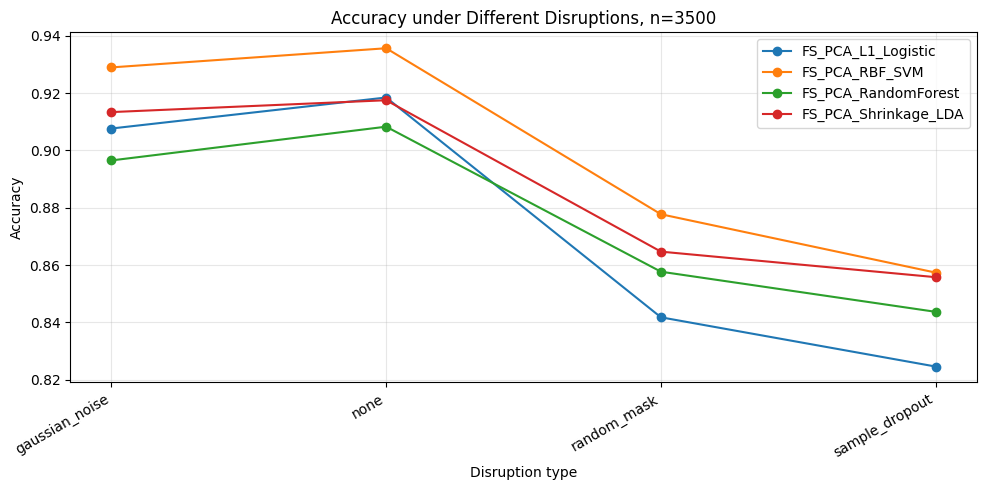

In [68]:
import matplotlib.pyplot as plt

selected_n = max(sample_sizes)

plot_df = disruption_summary[
    disruption_summary["n"] == selected_n
].copy()

plt.figure(figsize=(10, 5))



for model_name in plot_df["model"].unique():

    print(model_name)
    temp = plot_df[plot_df["model"] == model_name]

    plt.plot(
        temp["disruption"],
        temp["accuracy_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Disruption type")
plt.ylabel("Accuracy")
plt.title(f"Accuracy under Different Disruptions, n={selected_n}")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

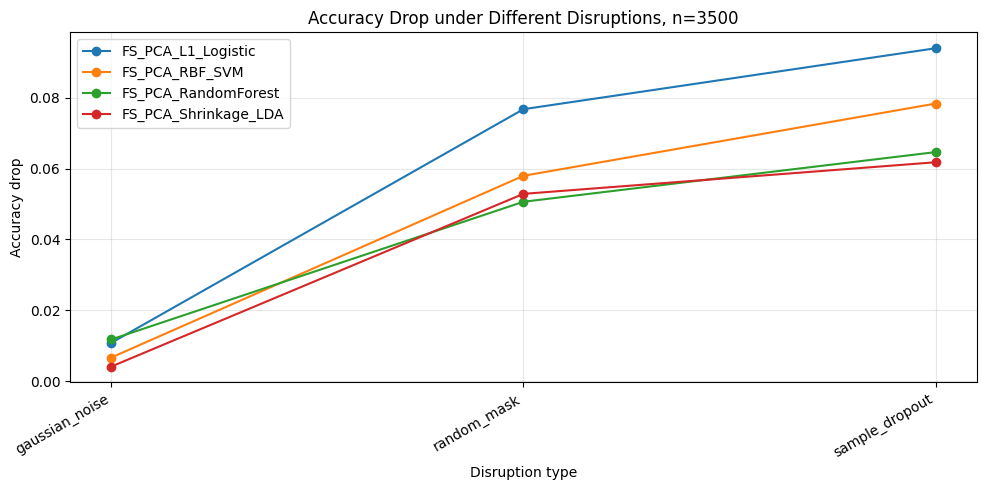

In [60]:
plot_df = disruption_summary[
    (disruption_summary["n"] == selected_n) &
    (disruption_summary["disruption"] != "none")
].copy()

plt.figure(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    temp = plot_df[plot_df["model"] == model_name]

    plt.plot(
        temp["disruption"],
        temp["accuracy_drop_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Disruption type")
plt.ylabel("Accuracy drop")
plt.title(f"Accuracy Drop under Different Disruptions, n={selected_n}")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

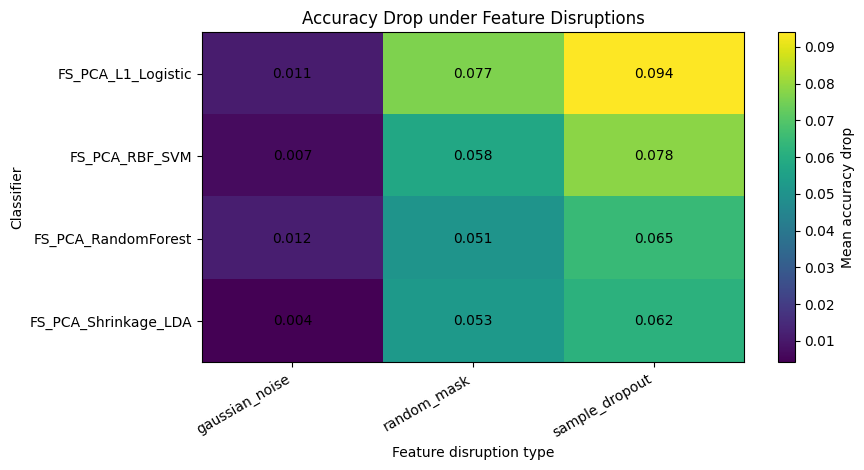

In [63]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Remove clean baseline
heatmap_df = disruption_summary[
    disruption_summary["disruption"] != "none"
].copy()

heatmap_data = heatmap_df.pivot(
    index="model",
    columns="disruption",
    values="accuracy_drop_mean"
)

plt.figure(figsize=(9, 4.8))

plt.imshow(heatmap_data.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.colorbar(label="Mean accuracy drop")

plt.title("Accuracy Drop under Feature Disruptions")
plt.xlabel("Feature disruption type")
plt.ylabel("Classifier")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.values[i, j]
        plt.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig("part1b_feature_disruption_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Question 1 c

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone


def detect_potential_mislabels(
    X,
    y,
    model,
    labels,
    cv_folds=3,
    threshold_true_prob=0.20,
    threshold_pred_conf=0.70
):
    """
    Detect potentially mislabeled observations using out-of-fold predicted probabilities.

    A sample is flagged if:
    1. predicted label != given label
    2. probability assigned to given label is low
    3. probability assigned to predicted label is high
    """

    y = np.array(y)
    labels = np.array(labels)

    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=0
    )

    model_clone = clone(model)

    prob_oof = cross_val_predict(
        model_clone,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )

    pred_indices = np.argmax(prob_oof, axis=1)
    y_pred = labels[pred_indices]

    label_to_index = {label: i for i, label in enumerate(labels)}

    true_prob = np.array([
        prob_oof[i, label_to_index[y[i]]]
        for i in range(len(y))
    ])

    pred_conf = np.max(prob_oof, axis=1)

    suspicious_score = pred_conf - true_prob

    flagged = (
        (y_pred != y) &
        (true_prob < threshold_true_prob) &
        (pred_conf > threshold_pred_conf)
    )

    result_df = pd.DataFrame({
        "index": np.arange(len(y)),
        "given_label": y,
        "predicted_label": y_pred,
        "true_label_probability": true_prob,
        "predicted_label_probability": pred_conf,
        "suspicious_score": suspicious_score,
        "flagged_as_potential_mislabel": flagged
    })

    result_df = result_df.sort_values(
        "suspicious_score",
        ascending=False
    ).reset_index(drop=True)

    return result_df

In [ ]:
labels = np.unique(y_TR)

model_for_detection = pipelines["RBF_SVM"]

mislabel_result = detect_potential_mislabels(
    X=X_TR,
    y=y_TR,
    model=model_for_detection,
    labels=labels,
    cv_folds=3,
    threshold_true_prob=0.20,
    threshold_pred_conf=0.70
)

mislabel_result.head(20)

In [ ]:
mislabel_result.to_csv(
    "part1c_potential_mislabels_original_data.csv",
    index=False
)

In [ ]:
n_flagged = mislabel_result["flagged_as_potential_mislabel"].sum()

print("Number of potential mislabeled observations:", n_flagged)


In [ ]:
def inject_mislabels(y, fraction=0.05, seed=0):
    """
    Randomly flip a fraction of labels to incorrect labels.
    """

    rng = np.random.default_rng(seed)

    y = np.array(y).copy()
    labels = np.unique(y)

    n_samples = len(y)
    n_flip = int(fraction * n_samples)

    flip_indices = rng.choice(
        np.arange(n_samples),
        size=n_flip,
        replace=False
    )

    y_corrupted = y.copy()

    for idx in flip_indices:
        original_label = y[idx]
        possible_wrong_labels = labels[labels != original_label]
        new_label = rng.choice(possible_wrong_labels)
        y_corrupted[idx] = new_label

    return y_corrupted, flip_indices


y_corrupted, injected_mislabel_indices = inject_mislabels(
    y=y_TR,
    fraction=0.05,
    seed=42
)

print("Number of injected mislabeled observations:", len(injected_mislabel_indices))

mislabel_result_corrupted = detect_potential_mislabels(
    X=X_TR,
    y=y_corrupted,
    model=model_for_detection,
    labels=np.unique(y_corrupted),
    cv_folds=3,
    threshold_true_prob=0.20,
    threshold_pred_conf=0.70
)

mislabel_result_corrupted.to_csv(
    "part1c_potential_mislabels_corrupted_data.csv",
    index=False
)



In [ ]:
flagged_indices = mislabel_result_corrupted[
    mislabel_result_corrupted["flagged_as_potential_mislabel"] == True
]["index"].values

injected_set = set(injected_mislabel_indices)
flagged_set = set(flagged_indices)

true_detected = injected_set.intersection(flagged_set)

detection_recall = len(true_detected) / len(injected_set)

if len(flagged_set) > 0:
    detection_precision = len(true_detected) / len(flagged_set)
else:
    detection_precision = 0

print("Injected mislabeled observations:", len(injected_set))
print("Flagged observations:", len(flagged_set))
print("Injected mislabeled observations detected:", len(true_detected))
print("Detection recall:", detection_recall)
print("Detection precision:", detection_precision)

part1c_summary = pd.DataFrame({
    "Metric": [
        "Injected mislabeled observations",
        "Flagged observations",
        "Injected mislabeled observations detected",
        "Detection recall",
        "Detection precision"
    ],
    "Value": [
        len(injected_set),
        len(flagged_set),
        len(true_detected),
        detection_recall,
        detection_precision
    ]
})

part1c_summary

part1c_summary.to_csv(
    "part1c_mislabel_detection_summary.csv",
    index=False
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

mislabel_result = pd.read_csv("part1c_potential_mislabels_original_data.csv")

plt.figure(figsize=(8, 5))

plt.hist(
    mislabel_result["suspicious_score"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Suspicious score")
plt.ylabel("Number of observations")
plt.title("Distribution of Suspicious Scores in Original Data")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("part1c_suspicious_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# flagged_indices: 被检测方法标记为 suspicious 的样本 index
# injected_mislabel_indices: 人为注入错误标签的样本 index

flagged_set = set(flagged_indices)
injected_set = set(injected_mislabel_indices)

detected_injected = len(injected_set.intersection(flagged_set))
missed_injected = len(injected_set - flagged_set)
false_flags = len(flagged_set - injected_set)

plot_values = [
    detected_injected,
    missed_injected,
    false_flags
]

plot_labels = [
    "Injected mislabels detected",
    "Injected mislabels missed",
    "Other flagged observations"
]

plt.figure(figsize=(8, 5))

plt.bar(plot_labels, plot_values)

plt.ylabel("Number of observations")
plt.title("Detection Result after Injecting Mislabeled Observations")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("part1c_injected_mislabel_detection.png", dpi=300, bbox_inches="tight")
plt.show()